# Linear Regression notebook

In the last notebook I got all of the features and am now working to go and create a linear regression of the intensity of the dataset using the features. I will accomplish the linear regression part and then move on to later in the file the logisitc regression whos component will be found in minilearn.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())



Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


Just make sure everything is here and working

In [2]:
features = pd.read_csv("data/processed/features.csv")

print(features.head())
print(features.shape)




                   filename                                filepath  \
0  03-01-01-01-01-01-01.wav  data\Actor_01\03-01-01-01-01-01-01.wav   
1  03-01-01-01-01-02-01.wav  data\Actor_01\03-01-01-01-01-02-01.wav   
2  03-01-01-01-02-01-01.wav  data\Actor_01\03-01-01-01-02-01-01.wav   
3  03-01-01-01-02-02-01.wav  data\Actor_01\03-01-01-01-02-02-01.wav   
4  03-01-02-01-01-01-01.wav  data\Actor_01\03-01-02-01-01-01-01.wav   

   modality_number    modality  vocal_channel_number vocal_channel  \
0                3  audio-only                     1        speech   
1                3  audio-only                     1        speech   
2                3  audio-only                     1        speech   
3                3  audio-only                     1        speech   
4                3  audio-only                     1        speech   

   emotion_code  emotion  intensity_number intensity  ...  spec_centroid_min  \
0             1  neutral                 1    normal  ...           0.00

So this has been harder then first expected. My intial results on my 480 feature set and 2450 rows of data has been dissapointing. It seems like the amount of features are being dramatically overfit in this situation. Especially on my features which seem to have a large amount of correlation. So, the first results before tweaking the feature set was a test MSE of 5.19 and a test R^2 of -20.0301 which I didn't think was possible

Second round conclusions: I have changed the code to take out the nuetral emotion in the feature set because I am predicting normal on a nuetral emotion and double counting on the feature set.I got a test MSE of 4.15 and then a test R^2 of -15.615

Third round conclusion: After removing all features that don't end with mean I was given a Test of .19 MSE which is slightly higher then the train value at .17 and then a R^2 of 0.2957 on train and a train R^2 of 0.2392. These numbers are not great but it is atleast in the realm of possibility

In [14]:
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.preprocessing.Scaler import StandardScaler
 
no_nuetral_df = features.drop(features[features["emotion"] == "neutral"].index).copy()

complete_df = no_nuetral_df.copy()

only_mean_features = [k for k in complete_df.columns
                    if k.endswith("_mean")]

X = complete_df[only_mean_features]
y = complete_df["intensity_number"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20, shuffle=True)

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print(mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_test, y_pred_test))
print(f"  Train R2:  {r2_score(y_train, y_pred_train):.4f}")
print(f"  Test R2:   {r2_score(y_test, y_pred_test):.4f}")

Train shape: (1811, 120)
Test shape: (452, 120)
0.17607269771608752
0.19014536543288085
  Train R2:  0.2957
  Test R2:   0.2392


This is the third iterations graph between the two different intensitys. Linear regression is not good for tasks that are basically classifier between two different numbers. Those like a 1 and 2 for intensity. However, this graph shows all of our predictions and then the actual predicted line by the model

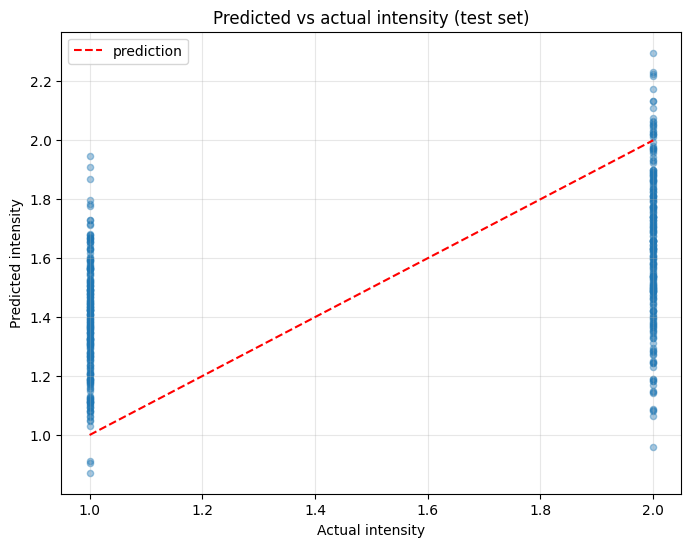

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.4, s=20)
plt.plot([1, 2], [1, 2], "r--", label="prediction")
plt.xlabel("Actual intensity")
plt.ylabel("Predicted intensity")
plt.title("Predicted vs actual intensity (test set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()